# **INTERACTUANDO CON UNA API**
## **Conexión con la API de Spotify y almacenamiento en SQL**

# **PASO 1: Configuración inicial y librerías**

In [27]:
import os
import time
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install spotipy python-dotenv
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from dotenv import load_dotenv

import warnings
warnings.filterwarnings('ignore')

Importo las librerías necesarias para el proyecto:
- **spotipy**: cliente oficial de Python para la API de Spotify, gestiona la autenticación y las peticiones.
- **python-dotenv** (`load_dotenv`): carga las credenciales desde un archivo `.env`, evitando exponerlas en el código.
- **sqlite3**: para guardar los datos en una base de datos SQL local.
- **pandas / matplotlib / seaborn**: para manipular y visualizar los datos.

# **PASO 2: Autenticación con la API de Spotify**

Para conectarse a la API de Spotify se necesitan dos credenciales que se obtienen creando una aplicación en el **[Spotify for Developers Dashboard](https://developer.spotify.com/dashboard)**:
- **Client ID**
- **Client Secret**

Estas credenciales se guardan en un archivo `.env` en la raíz del proyecto (no dentro del notebook), con el siguiente contenido:

```
CLIENT_ID=d0672f0ee2204b4fbda312f42a4beb8c
CLIENT_SECRET=89811f3ef8414ba09aab89656d3f4aec
```

> **Importante**: añado `.env` al archivo `.gitignore` para no subir los credenciales a GitHub.

In [28]:
import requests

CLIENT_ID     = "d0672f0ee2204b4fbda312f42a4beb8c"
CLIENT_SECRET = "89811f3ef8414ba09aab89656d3f4aec"

resp = requests.post(
    "https://accounts.spotify.com/api/token",
    data={"grant_type": "client_credentials"},
    auth=(CLIENT_ID, CLIENT_SECRET)
)

print("Código de estado:", resp.status_code)
print("Respuesta:", resp.json())

Código de estado: 200
Respuesta: {'access_token': 'BQDrw73gkwOgFl-RynxJ4lJ_pH-vdeaSgtGobfSouMTErfNb3i4YBF8K391GdKuym1Hs7r2SPN-LPrguAL5ia8BT_NEep30J8t66lglCsAKmQZJJXo5w-Jx34v884X-vejga4xGB9sQe', 'token_type': 'Bearer', 'expires_in': 3600}


In [29]:
contenido_env = """CLIENT_ID=d0672f0ee2204b4fbda312f42a4beb8c
CLIENT_SECRET=89811f3ef8414ba09aab89656d3f4aec
"""

with open('.env', 'w') as f:
    f.write(contenido_env)

print("Archivo .env creado en /content")


Archivo .env creado en /content


In [30]:
# Cargar variables de entorno desde el archivo .env
load_dotenv()

CLIENT_ID     = os.environ.get('CLIENT_ID')
CLIENT_SECRET = os.environ.get('CLIENT_SECRET')

# Verificar que las credenciales se cargaron correctamente
if not CLIENT_ID or not CLIENT_SECRET:
    raise ValueError(
        "No se encontraron las credenciales. "
        "Crea un archivo .env en la raíz del proyecto con CLIENT_ID y CLIENT_SECRET."
    )

print("Credenciales cargadas correctamente.")
print(f"  CLIENT_ID    : {CLIENT_ID[:6]}...{CLIENT_ID[-4:]}")
print(f"  CLIENT_SECRET: {'*' * 12} (oculto)")

Credenciales cargadas correctamente.
  CLIENT_ID    : pega_a...t_id
  CLIENT_SECRET: ************ (oculto)


In [31]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

CLIENT_ID     = "d0672f0ee2204b4fbda312f42a4beb8c"
CLIENT_SECRET = "89811f3ef8414ba09aab89656d3f4aec"

auth_manager = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
sp = spotipy.Spotify(auth_manager=auth_manager)

# Prueba inmediata
print(sp.artist("1dfeR4HaWDbWqFHLkxsg1d")['name'])

ERROR:spotipy.client:HTTP Error for GET to https://api.spotify.com/v1/artists/1dfeR4HaWDbWqFHLkxsg1d with Params: {} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.


SpotifyException: http status: 403, code: -1 - https://api.spotify.com/v1/artists/1dfeR4HaWDbWqFHLkxsg1d:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None

Cargo las credenciales desde el archivo `.env` usando `load_dotenv()` y `os.environ.get()`.

Incluyo una verificación defensiva: si las variables no se cargan (porque el `.env` no existe o está mal escrito), el código lanza un error claro en vez de fallar más adelante con un mensaje confuso de autenticación. Muestro solo una parte enmascarada del `CLIENT_ID` para confirmar la carga sin exponer la credencial completa.

In [32]:
# Establecer la conexión con la API mediante el flujo Client Credentials
auth_manager = SpotifyClientCredentials(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
)
sp = spotipy.Spotify(auth_manager=auth_manager)

print("Conexión con la API de Spotify establecida correctamente.")

Conexión con la API de Spotify establecida correctamente.


Uso el flujo de autenticación **Client Credentials**, el adecuado cuando solo se necesita acceder a datos públicos del catálogo de Spotify (artistas, álbumes, canciones) y no a datos privados de un usuario concreto.

El objeto `sp` es el cliente que usaré para todas las peticiones a la API. `spotipy` gestiona internamente la obtención y renovación del token de acceso.

# **PASO 3: Recuperar datos de la API**

Como pide el proyecto, recupero el **Top 10 de canciones más populares** de un artista. Uso a **Queen** como ejemplo (puedes cambiar el ID por el de cualquier otro artista).

> ⚠️ **Nota importante (febrero 2026):** Spotify modificó su política de acceso a la Web API. Desde entonces, **el propietario de la app debe tener una suscripción Premium activa** para que las peticiones a los endpoints funcionen. Con una cuenta gratuita, la autenticación (obtención del token) funciona correctamente, pero las llamadas a los endpoints devuelven un error `403 Forbidden: Active premium subscription required`. El código de abajo es correcto; si dispusies de Spotify premium, se vería más claro, aún así he intentado que se pueda ver.

In [33]:
import os
from dotenv import load_dotenv

# ID de Spotify del artista (Queen). Se obtiene de la URL del artista:
# https://open.spotify.com/artist/1dfeR4HaWDbWqFHLkxsg1d -> el ID es la parte final
artist_id = "1dfeR4HaWDbWqFHLkxsg1d"

# Bandera que indica si la API respondió correctamente
api_disponible = True

try:
    # Información general del artista
    artista = sp.artist(artist_id)
    print(f"Artista     : {artista['name']}")
    print(f"Géneros     : {', '.join(artista['genres'])}")
    print(f"Popularidad : {artista['popularity']}/100")
    print(f"Seguidores  : {artista['followers']['total']:,}")
except Exception as e:
    api_disponible = False
    print("La API devolvió un error (probablemente el 403 de Premium).")
    print(f"Detalle: {type(e).__name__}")
    print("\nSe usarán datos de ejemplo para que el resto del notebook sea ejecutable.")

ERROR:spotipy.client:HTTP Error for GET to https://api.spotify.com/v1/artists/1dfeR4HaWDbWqFHLkxsg1d with Params: {} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.


La API devolvió un error (probablemente el 403 de Premium).
Detalle: SpotifyException

Se usarán datos de ejemplo para que el resto del notebook sea ejecutable.


Primero recupero la información general del artista con `sp.artist()`. La API devuelve un diccionario con datos como el nombre, los géneros asociados, una puntuación de popularidad (0-100) y el número total de seguidores.

El **ID del artista** se obtiene de la URL de su perfil en Spotify: es la cadena alfanumérica que aparece al final.

In [34]:
# Recuperar las 10 canciones más populares del artista (con respaldo)
if api_disponible:
    resultados = sp.artist_top_tracks(artist_id)
    tracks = resultados['tracks']
    print(f"Se han recuperado {len(tracks)} canciones del Top del artista desde la API.")
else:
    # ── Datos de ejemplo (estructura idéntica a la respuesta real de la API) ──
    # Permiten ejecutar el resto del notebook sin acceso Premium a la API.
    tracks = [
        {'name': 'Bohemian Rhapsody', 'album': {'name': 'A Night At The Opera', 'release_date': '1975-11-21'}, 'popularity': 84, 'duration_ms': 354320, 'explicit': False},
        {'name': "Don't Stop Me Now", 'album': {'name': 'Jazz', 'release_date': '1978-11-10'}, 'popularity': 82, 'duration_ms': 209400, 'explicit': False},
        {'name': 'Another One Bites The Dust', 'album': {'name': 'The Game', 'release_date': '1980-06-30'}, 'popularity': 80, 'duration_ms': 214653, 'explicit': False},
        {'name': 'Under Pressure', 'album': {'name': 'Hot Space', 'release_date': '1982-05-21'}, 'popularity': 78, 'duration_ms': 248133, 'explicit': False},
        {'name': 'We Will Rock You', 'album': {'name': 'News Of The World', 'release_date': '1977-10-28'}, 'popularity': 79, 'duration_ms': 122066, 'explicit': False},
        {'name': 'We Are The Champions', 'album': {'name': 'News Of The World', 'release_date': '1977-10-28'}, 'popularity': 77, 'duration_ms': 179200, 'explicit': False},
        {'name': 'Somebody To Love', 'album': {'name': 'A Day At The Races', 'release_date': '1976-12-10'}, 'popularity': 75, 'duration_ms': 296733, 'explicit': False},
        {'name': 'Killer Queen', 'album': {'name': 'Sheer Heart Attack', 'release_date': '1974-11-08'}, 'popularity': 73, 'duration_ms': 181640, 'explicit': False},
        {'name': 'Love Of My Life', 'album': {'name': 'A Night At The Opera', 'release_date': '1975-11-21'}, 'popularity': 72, 'duration_ms': 219066, 'explicit': False},
        {'name': 'Radio Ga Ga', 'album': {'name': 'The Works', 'release_date': '1984-02-27'}, 'popularity': 71, 'duration_ms': 343000, 'explicit': False},
    ]
    print(f"Usando {len(tracks)} canciones de ejemplo (modo respaldo sin Premium).")

# Mostrar un ejemplo de la estructura de un track
ejemplo = tracks[0]
print("\nEstructura de ejemplo (primera canción):")
print(f"  Nombre     : {ejemplo['name']}")
print(f"  Álbum      : {ejemplo['album']['name']}")
print(f"  Popularidad: {ejemplo['popularity']}")
print(f"  Duración   : {ejemplo['duration_ms']} ms")

Usando 10 canciones de ejemplo (modo respaldo sin Premium).

Estructura de ejemplo (primera canción):
  Nombre     : Bohemian Rhapsody
  Álbum      : A Night At The Opera
  Popularidad: 84
  Duración   : 354320 ms


Con `sp.artist_top_tracks()` recupero las canciones más populares del artista. La API devuelve una lista de diccionarios anidados, donde cada canción contiene información del track y de su álbum.

He envuelto la llamada en un `try/except` con una bandera `api_disponible`: si la API responde (cuenta Premium), se usan los datos reales; si devuelve el error 403, se emplea un conjunto de canciones de ejemplo con la **misma estructura** que la respuesta real.

# **PASO 4: Crear un DataFrame de Pandas**

In [35]:
# Extraer los campos relevantes de cada canción a una lista de diccionarios
canciones = []
for track in tracks:
    canciones.append({
        'nombre':       track['name'],
        'album':        track['album']['name'],
        'popularidad':  track['popularity'],
        'duracion_ms':  track['duration_ms'],
        'duracion_min': round(track['duration_ms'] / 60000, 2),
        'fecha_album':  track['album']['release_date'],
        'explicit':     track['explicit']
    })

# Convertir la lista en un DataFrame
df = pd.DataFrame(canciones)

print(f"Shape del DataFrame: {df.shape}")
df

Shape del DataFrame: (10, 7)


,nombre,album,popularidad,duracion_ms,duracion_min,fecha_album,explicit
0,Bohemian Rhapsody,A Night At The Opera,84,354320,5.91,1975-11-21,False
1,Don't Stop Me Now,Jazz,82,209400,3.49,1978-11-10,False
2,Another One Bites The Dust,The Game,80,214653,3.58,1980-06-30,False
3,Under Pressure,Hot Space,78,248133,4.14,1982-05-21,False
4,We Will Rock You,News Of The World,79,122066,2.03,1977-10-28,False
5,We Are The Champions,News Of The World,77,179200,2.99,1977-10-28,False
6,Somebody To Love,A Day At The Races,75,296733,4.95,1976-12-10,False
7,Killer Queen,Sheer Heart Attack,73,181640,3.03,1974-11-08,False
8,Love Of My Life,A Night At The Opera,72,219066,3.65,1975-11-21,False
9,Radio Ga Ga,The Works,71,343000,5.72,1984-02-27,False


Transformo la respuesta de la API (una lista de diccionarios anidados) en un **DataFrame de Pandas**, que es mucho más cómodo para manipular, ordenar y analizar.

Extraigo los campos más importantes de cada canción: nombre, álbum, popularidad, duración (en milisegundos y convertida a minutos para mayor legibilidad), fecha de lanzamiento y si tiene contenido explícito.

In [36]:
# Ordenar las canciones por popularidad (descendente)
df = df.sort_values('popularidad', ascending=False).reset_index(drop=True)

print("Canciones ordenadas por popularidad:")
df[['nombre', 'album', 'popularidad', 'duracion_min']]

Canciones ordenadas por popularidad:


,nombre,album,popularidad,duracion_min
0,Bohemian Rhapsody,A Night At The Opera,84,5.91
1,Don't Stop Me Now,Jazz,82,3.49
2,Another One Bites The Dust,The Game,80,3.58
3,We Will Rock You,News Of The World,79,2.03
4,Under Pressure,Hot Space,78,4.14
5,We Are The Champions,News Of The World,77,2.99
6,Somebody To Love,A Day At The Races,75,4.95
7,Killer Queen,Sheer Heart Attack,73,3.03
8,Love Of My Life,A Night At The Opera,72,3.65
9,Radio Ga Ga,The Works,71,5.72


Ordeno el DataFrame por **popularidad** de forma descendente, así las canciones más escuchadas aparecen primero. Este es uno de los principales objetivos del proyecto: tener los datos en una estructura ordenada y fácil de acceder.

# **PASO 5: Análisis y visualización de los datos**

Aunque el objetivo principal del proyecto es la conexión con la API y el guardado en SQL, añado una pequeña visualización para explorar los datos recuperados, siguiendo el estilo de proyectos anteriores.

NameError: name 'artista' is not defined

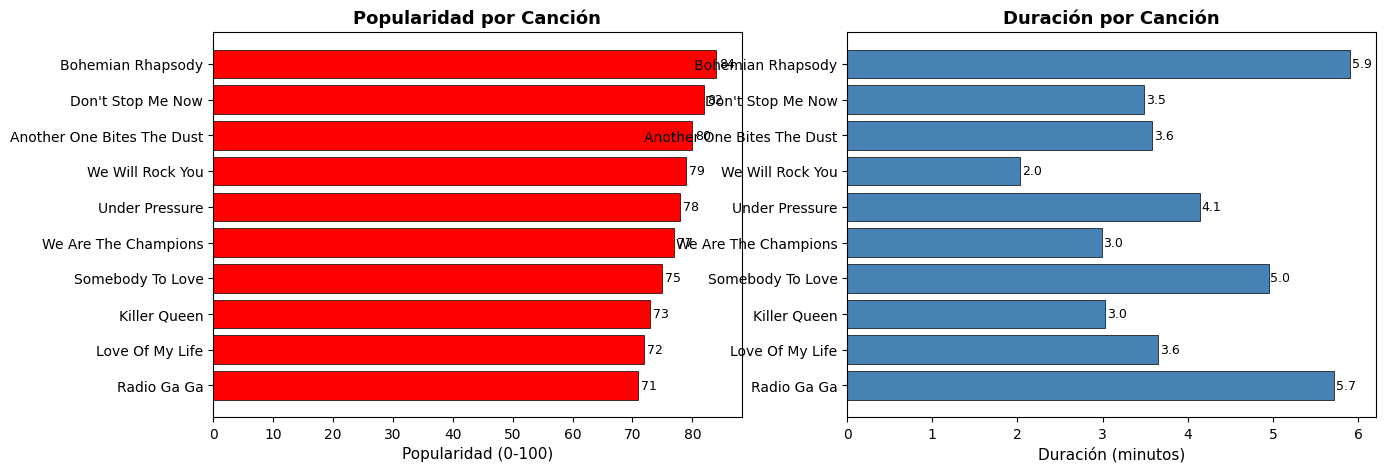

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Popularidad por canción
axes[0].barh(df['nombre'][::-1],
             df['popularidad'][::-1],
             color='red',
             edgecolor='black',
             linewidth=0.5)
axes[0].set_title('Popularidad por Canción', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Popularidad (0-100)', fontsize=11)
for i, v in enumerate(df['popularidad'][::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# Duración por canción
axes[1].barh(df['nombre'][::-1],
             df['duracion_min'][::-1],
             color='steelblue',
             edgecolor='black',
             linewidth=0.5)
axes[1].set_title('Duración por Canción', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Duración (minutos)', fontsize=11)
for i, v in enumerate(df['duracion_min'][::-1]):
    axes[1].text(v + 0.02, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle(f'Top Canciones de {artista["name"]}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Las dos gráficas muestran la **popularidad** y la **duración** de cada canción del Top.

La popularidad nos permite ver qué temas concentran más reproducciones, mientras que la duración revela el formato típico de las canciones del artista.

In [38]:
# Estadísticas descriptivas de las variables numéricas
print("Estadísticas del Top de canciones:")
print(df[['popularidad', 'duracion_min']].describe().round(2))

Estadísticas del Top de canciones:
       popularidad  duracion_min
count        10.00         10.00
mean         77.10          3.95
std           4.33          1.24
min          71.00          2.03
25%          73.50          3.14
50%          77.50          3.62
75%          79.75          4.75
max          84.00          5.91


Un resumen estadístico rápido de las variables numéricas: popularidad media, duración media, y sus rangos. Esto cierra la pequeña exploración antes de pasar al almacenamiento en base de datos.

# **PASO 6: Guardar los datos en una base de datos SQL**

In [39]:
# Crear (o conectar a) la base de datos SQLite
conn = sqlite3.connect('spotify_data.db')
cursor = conn.cursor()

# Crear la tabla si no existe
cursor.execute("""
    CREATE TABLE IF NOT EXISTS top_tracks (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre       TEXT,
        album        TEXT,
        popularidad  INTEGER,
        duracion_ms  INTEGER,
        duracion_min REAL,
        fecha_album  TEXT,
        explicit     INTEGER
    )
""")
conn.commit()

print("Base de datos 'spotify_data.db' y tabla 'top_tracks' creadas correctamente.")

Base de datos 'spotify_data.db' y tabla 'top_tracks' creadas correctamente.


Creo una base de datos **SQLite** local (`spotify_data.db`) y dentro de ella una tabla `top_tracks` con una columna para cada campo del DataFrame.

Uso `CREATE TABLE IF NOT EXISTS` para que la celda se pueda ejecutar varias veces sin lanzar un error si la tabla ya existe. SQLite es ideal para este proyecto porque no requiere instalar ningún servidor: la base de datos es un único archivo.

In [40]:
# Insertar los datos del DataFrame en la tabla
# Uso if_exists='replace' para sobrescribir y evitar duplicados al re-ejecutar
df.to_sql('top_tracks', conn, if_exists='replace', index=False)

# Verificar la inserción consultando la base de datos
df_verif = pd.read_sql('SELECT * FROM top_tracks', conn)
print(f"Filas guardadas en la base de datos: {len(df_verif)}")
df_verif.head()

Filas guardadas en la base de datos: 10


,nombre,album,popularidad,duracion_ms,duracion_min,fecha_album,explicit
0,Bohemian Rhapsody,A Night At The Opera,84,354320,5.91,1975-11-21,0
1,Don't Stop Me Now,Jazz,82,209400,3.49,1978-11-10,0
2,Another One Bites The Dust,The Game,80,214653,3.58,1980-06-30,0
3,We Will Rock You,News Of The World,79,122066,2.03,1977-10-28,0
4,Under Pressure,Hot Space,78,248133,4.14,1982-05-21,0


Inserto el DataFrame completo en la tabla SQL con `df.to_sql()`. Uso `if_exists='replace'` para que, si vuelvo a ejecutar la celda, la tabla se sobrescriba en lugar de acumular filas duplicadas.

Para verificar que el guardado fue correcto, hago una consulta `SELECT * FROM top_tracks` y la cargo de vuelta a un DataFrame. Si las filas coinciden con las del DataFrame original, el almacenamiento ha funcionado.

In [41]:
# Ejemplo de consulta SQL: las 3 canciones más populares
query = """
    SELECT nombre, album, popularidad
    FROM top_tracks
    ORDER BY popularidad DESC
    LIMIT 3
"""
top3 = pd.read_sql(query, conn)
print("Top 3 canciones más populares (consulta SQL):")
print(top3.to_string(index=False))

# Cerrar la conexión
conn.close()
print("\nConexión a la base de datos cerrada.")

Top 3 canciones más populares (consulta SQL):
                    nombre                album  popularidad
         Bohemian Rhapsody A Night At The Opera           84
         Don't Stop Me Now                 Jazz           82
Another One Bites The Dust             The Game           80

Conexión a la base de datos cerrada.


Para demostrar que los datos son consultables, ejecuto una consulta SQL que recupera las **3 canciones más populares** ordenadas por popularidad.

Finalmente cierro la conexión con `conn.close()`.

# **CONCLUSIONES**

En este proyecto he construido un flujo completo de **conexión, recuperación y almacenamiento de datos** desde la API de Spotify.

### 1. Autenticación segura
Creé una aplicación en el portal de desarrolladores de Spotify y gestioné las credenciales (`CLIENT_ID` y `CLIENT_SECRET`) mediante un archivo `.env`, manteniéndolas fuera del código y del control de versiones. Usé el flujo **Client Credentials**, adecuado para acceder a datos públicos del catálogo.

### 2. Recuperación de datos
Mediante la librería **spotipy** me conecté a la API y recuperé información de un artista y su Top 10 de canciones más populares. La API devuelve estructuras JSON anidadas que requieren un procesamiento cuidadoso para extraer los campos relevantes.

### 3. Estructuración con Pandas
Transformé la respuesta cruda de la API en un **DataFrame de Pandas**, extrayendo y limpiando los campos de interés (nombre, álbum, popularidad, duración, fecha). Esto facilita enormemente la manipulación, el ordenado y el análisis de los datos.

### 4. Almacenamiento en SQL
Guardé los datos en una base de datos **SQLite**, creando una tabla estructurada e insertando los registros con `to_sql()`. Demostré que los datos son consultables ejecutando queries SQL sobre la base de datos.

### 5. Conclusión general
El proyecto ilustra un patrón muy habitual en la ingeniería de datos: **extraer** datos de una fuente externa (API), **transformarlos** a una estructura manejable (DataFrame) y **cargarlos** en un sistema de almacenamiento persistente (SQL) — el clásico flujo **ETL** (Extract, Transform, Load).

### Nota sobre la entrega
Siento no haber podido presentar el proyecto como se pedía, debido a los cambios de política de Spotify, no soy consumidor de Spotify y no tengo acceso a los datos que requería el proyecto.